In [11]:

!pip install "rembg[cpu]" onnxruntime

!pip install rembg onnxruntime gradio pillow

INFO: pip is looking at multiple versions of gradio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.2/31.2 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: starlette
    Found existing installation: starlette 0.52.1
    Uninstalling starlette-0.52.1:
      Successfully uninstalled starlette-0.52.1
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

In [12]:
from rembg import remove
from PIL import Image
import numpy as np
import gradio as gr

In [13]:
def remove_bg(image):
    # image comes as numpy array from gradio
    input_image = Image.fromarray(image)

    # AI background removal
    output = remove(input_image)

    return output

In [14]:
interface = gr.Interface(
    fn=remove_bg,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Image(type="pil", label="No Background Image"),
    title=" AI Background Remover",
    description="Upload an image and AI will remove the background using U2Net model (rembg)."
)

In [15]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4134323f1d5465b740.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [7]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-02-25 at 10.38.30 PM.jpeg to WhatsApp Image 2026-02-25 at 10.38.30 PM (1).jpeg


In [8]:
from rembg import remove
from PIL import Image

input_path = list(uploaded.keys())[0]

input_image = Image.open(input_path)

output_image = remove(input_image)

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

In [9]:
output_path = "no_bg.png"
output_image.save(output_path)

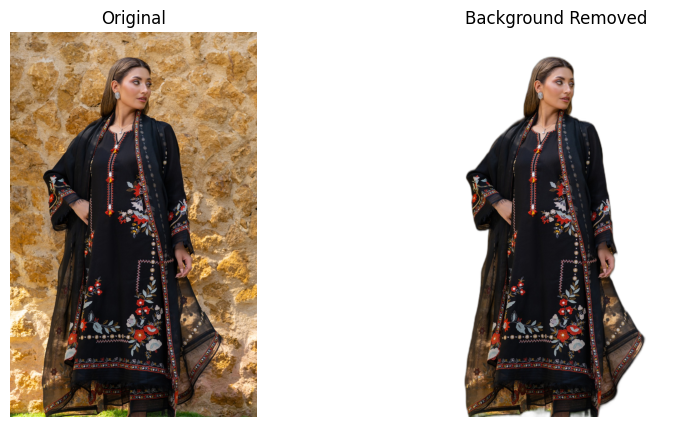

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(input_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output_image)
plt.title("Background Removed")
plt.axis("off")

plt.show()